In [3]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")

 Step 1: Data Collection & Loading

In [4]:
df = pd.read_csv("ai_job_dataset.csv")

In [5]:
df.size

285000

In [6]:
df.columns

Index(['job_id', 'job_title', 'salary_usd', 'salary_currency',
       'experience_level', 'employment_type', 'company_location',
       'company_size', 'employee_residence', 'remote_ratio', 'required_skills',
       'education_required', 'years_experience', 'industry', 'posting_date',
       'application_deadline', 'job_description_length', 'benefits_score',
       'company_name'],
      dtype='object')

# column structure
1. Job_id: Unique identification number assigned to each employee.
2. Job_title: Designation or role offered.
    Example: AI Research Scientist, AI Software Engineer, AI Specialist
3. Salary_usd: Estimated annual salary offered for the job in usd.
4. salary_currency: Currency in which the salary is originally offered.
    Example: USD, EUR
5. experience_level: Required experience level for the role.
    Example: EN(Entry Level), MI(Mid Level), SE(Senior Level)
6. employment_type: Type of employment offered.
    Example: FT(Full Time), PT(Part Time),CT(Contract)
7. company_location: Country where the company is located or hiring location.
    Example: India, China, Canada, Switzerland
8. company_size: Size of the company.
    Example: S(Small), M(Medium), L(Large)
9. employee_residence:  Country where the employee lives.
10. remote_ratio: How much remote work is allowed.
11. required_skills: Skills needed for the job.
    Example: Python, SQL, Machine Learning
12. education_required: Minimum educational qualification required.
    Example: Bachelor, Master, Associate
13. years_experience: Number of years of work experience required for the job.
14. industry:  Business sector of the company.
15. posting_date: Date when the job was posted.
16. application_deadline: Last date to apply for the job.
17. job_description_length: Length of the job description.
18. benefits_score: Score showing the quality of company benefits.
19. company_name: Name of the company offering the job.

Step 2: Initial Data Inspection

In [7]:
df.head()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,AI00001,AI Research Scientist,90376,USD,SE,CT,China,M,China,50,"Tableau, PyTorch, Kubernetes, Linux, NLP",Bachelor,9,Automotive,2024-10-18,2024-11-07,1076,5.9,Smart Analytics
1,AI00002,AI Software Engineer,61895,USD,EN,CT,Canada,M,Ireland,100,"Deep Learning, AWS, Mathematics, Python, Docker",Master,1,Media,2024-11-20,2025-01-11,1268,5.2,TechCorp Inc
2,AI00003,AI Specialist,152626,USD,MI,FL,Switzerland,L,South Korea,0,"Kubernetes, Deep Learning, Java, Hadoop, NLP",Associate,2,Education,2025-03-18,2025-04-07,1974,9.4,Autonomous Tech
3,AI00004,NLP Engineer,80215,USD,SE,FL,India,M,India,50,"Scala, SQL, Linux, Python",PhD,7,Consulting,2024-12-23,2025-02-24,1345,8.6,Future Systems
4,AI00005,AI Consultant,54624,EUR,EN,PT,France,S,Singapore,100,"MLOps, Java, Tableau, Python",Master,0,Media,2025-04-15,2025-06-23,1989,6.6,Advanced Robotics


In [8]:
df.tail()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
14995,AI14996,Robotics Engineer,38604,USD,EN,FL,Finland,S,Finland,50,"Java, Kubernetes, Azure",Bachelor,1,Energy,2025-02-06,2025-03-25,1635,7.9,Advanced Robotics
14996,AI14997,Machine Learning Researcher,57811,GBP,EN,CT,United Kingdom,M,United Kingdom,0,"Mathematics, Docker, SQL, Deep Learning",Master,0,Government,2024-10-16,2024-10-30,1624,8.2,Smart Analytics
14997,AI14998,NLP Engineer,189490,USD,EX,CT,South Korea,L,South Korea,50,"Scala, Spark, NLP",Associate,17,Manufacturing,2024-03-19,2024-05-02,1336,7.4,AI Innovations
14998,AI14999,Head of AI,79461,EUR,EN,FT,Netherlands,M,Netherlands,0,"Java, Computer Vision, Python, TensorFlow",PhD,1,Real Estate,2024-03-22,2024-04-23,1935,5.6,Smart Analytics
14999,AI15000,Computer Vision Engineer,56481,USD,MI,PT,Austria,S,Austria,50,"Scala, Azure, Deep Learning, GCP, Mathematics",PhD,2,Technology,2024-07-18,2024-08-10,2492,7.6,AI Innovations


In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 19 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   job_id                  15000 non-null  object 
 1   job_title               15000 non-null  object 
 2   salary_usd              15000 non-null  int64  
 3   salary_currency         15000 non-null  object 
 4   experience_level        15000 non-null  object 
 5   employment_type         15000 non-null  object 
 6   company_location        15000 non-null  object 
 7   company_size            15000 non-null  object 
 8   employee_residence      15000 non-null  object 
 9   remote_ratio            15000 non-null  int64  
 10  required_skills         15000 non-null  object 
 11  education_required      15000 non-null  object 
 12  years_experience        15000 non-null  int64  
 13  industry                15000 non-null  object 
 14  posting_date            15000 non-null

In [10]:
df.describe()

,salary_usd,remote_ratio,years_experience,job_description_length,benefits_score
count,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,115348.965133,49.483333,6.253200,1503.314733,7.504273
std,60260.940438,40.812712,5.545768,576.127083,1.450870
min,32519.000000,0.000000,0.000000,500.000000,5.000000
25%,70179.750000,0.000000,2.000000,1003.750000,6.200000
50%,99705.000000,50.000000,5.000000,1512.000000,7.500000
75%,146408.500000,100.000000,10.000000,2000.000000,8.800000
max,399095.000000,100.000000,19.000000,2499.000000,10.000000


In [11]:
df.dtypes

job_id                     object
job_title                  object
salary_usd                  int64
salary_currency            object
experience_level           object
employment_type            object
company_location           object
company_size               object
employee_residence         object
remote_ratio                int64
required_skills            object
education_required         object
years_experience            int64
industry                   object
posting_date               object
application_deadline       object
job_description_length      int64
benefits_score            float64
company_name               object
dtype: object

In [12]:
df.isnull()

,job_id,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,posting_date,application_deadline,job_description_length,benefits_score,company_name
0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
14995,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14996,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14997,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False
14998,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False


In [13]:
df.isnull().sum()

job_id                    0
job_title                 0
salary_usd                0
salary_currency           0
experience_level          0
employment_type           0
company_location          0
company_size              0
employee_residence        0
remote_ratio              0
required_skills           0
education_required        0
years_experience          0
industry                  0
posting_date              0
application_deadline      0
job_description_length    0
benefits_score            0
company_name              0
dtype: int64

In [14]:
df.apply(lambda x: x.unique())

job_id                    [AI00001, AI00002, AI00003, AI00004, AI00005, ...
job_title                 [AI Research Scientist, AI Software Engineer, ...
salary_usd                [90376, 61895, 152626, 80215, 54624, 123574, 7...
salary_currency                                             [USD, EUR, GBP]
experience_level                                           [SE, EN, MI, EX]
employment_type                                            [CT, FL, PT, FT]
company_location          [China, Canada, Switzerland, India, France, Ge...
company_size                                                      [M, L, S]
employee_residence        [China, Ireland, South Korea, India, Singapore...
remote_ratio                                                   [50, 100, 0]
required_skills           [Tableau, PyTorch, Kubernetes, Linux, NLP, Dee...
education_required                       [Bachelor, Master, Associate, PhD]
years_experience          [9, 1, 2, 7, 0, 3, 5, 8, 15, 6, 4, 16, 10, 18,...
industry    

In [15]:
# unique values
df.nunique()

job_id                    15000
job_title                    20
salary_usd                14315
salary_currency               3
experience_level              4
employment_type               4
company_location             20
company_size                  3
employee_residence           20
remote_ratio                  3
required_skills           13663
education_required            4
years_experience             20
industry                     15
posting_date                486
application_deadline        543
job_description_length     2000
benefits_score               51
company_name                 16
dtype: int64

In [16]:
for col in df.columns:
    print("\nColumn:", col)
    print(df[col].value_counts())


Column: job_id
job_id
AI00001    1
AI00002    1
AI00003    1
AI00004    1
AI00005    1
          ..
AI14996    1
AI14997    1
AI14998    1
AI14999    1
AI15000    1
Name: count, Length: 15000, dtype: int64

Column: job_title
job_title
Machine Learning Researcher    808
AI Software Engineer           784
Autonomous Systems Engineer    777
Machine Learning Engineer      772
AI Architect                   771
Head of AI                     765
NLP Engineer                   762
Robotics Engineer              759
Data Analyst                   759
AI Research Scientist          756
Data Engineer                  749
AI Product Manager             743
Research Scientist             742
Principal Data Scientist       734
AI Specialist                  728
ML Ops Engineer                725
Computer Vision Engineer       724
Data Scientist                 720
Deep Learning Engineer         718
AI Consultant                  704
Name: count, dtype: int64

Column: salary_usd
salary_usd
51000  

In [17]:
df["company_size"].value_counts() # example 

company_size
S    5007
L    4998
M    4995
Name: count, dtype: int64

In [18]:
df.duplicated().sum()

np.int64(0)

Step 3: Data Cleaning

In [19]:
print("Number of duplicates present:",df.duplicated().sum())
df = df.drop_duplicates()

Number of duplicates present: 0


In [20]:
# Handling Missing Values

# Numerical columns
num_cols = df.select_dtypes(include=['int64','float64']).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

In [21]:
# Categorical columns
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [22]:
# Convert Date Columns
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

In [23]:
# Standardize Column Names
df.columns = df.columns.str.lower().str.strip()

Step 4: Exploratory Data Analysis (EDA)

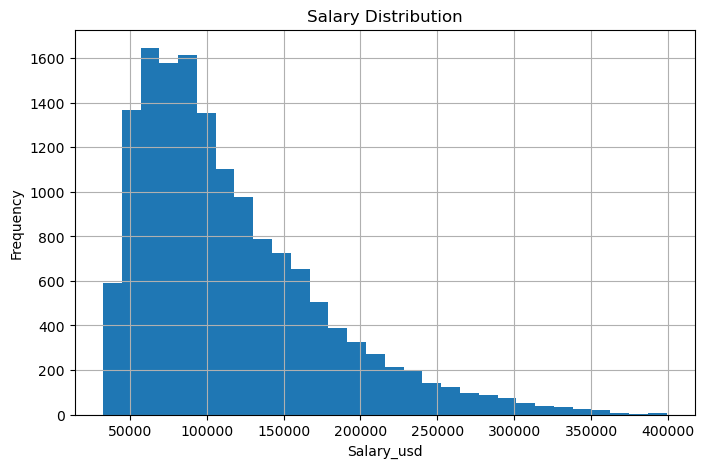

In [24]:
# Univariate Analysis
# Salary Distribution
plt.figure(figsize=(8,5))
df["salary_usd"].hist(bins=30)
plt.title("Salary Distribution")
plt.xlabel("Salary_usd")
plt.ylabel("Frequency")
plt.show()

In [25]:
# Check Skewness
print("\nSalary Skewness:")
print(df['salary_usd'].skew())


Salary Skewness:
1.2527592133197596


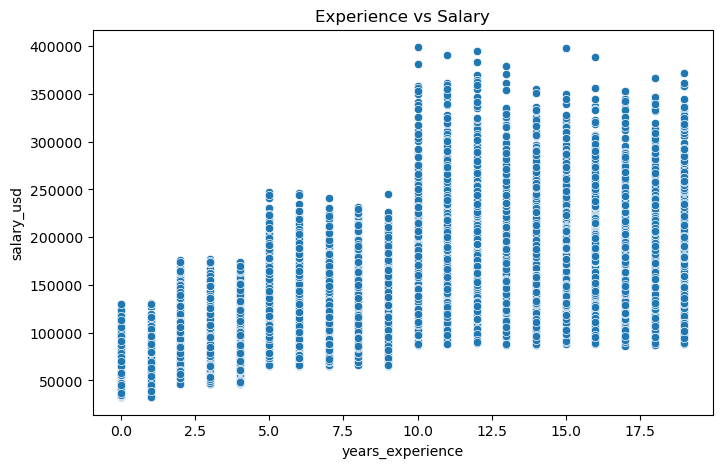

In [26]:
# Bivariate Analysis

# Feature vs Target relationship (Experience vs Salary)
plt.figure(figsize=(8,5))
sns.scatterplot(x="years_experience",y="salary_usd",data=df)
plt.title("Experience vs Salary")
plt.show()

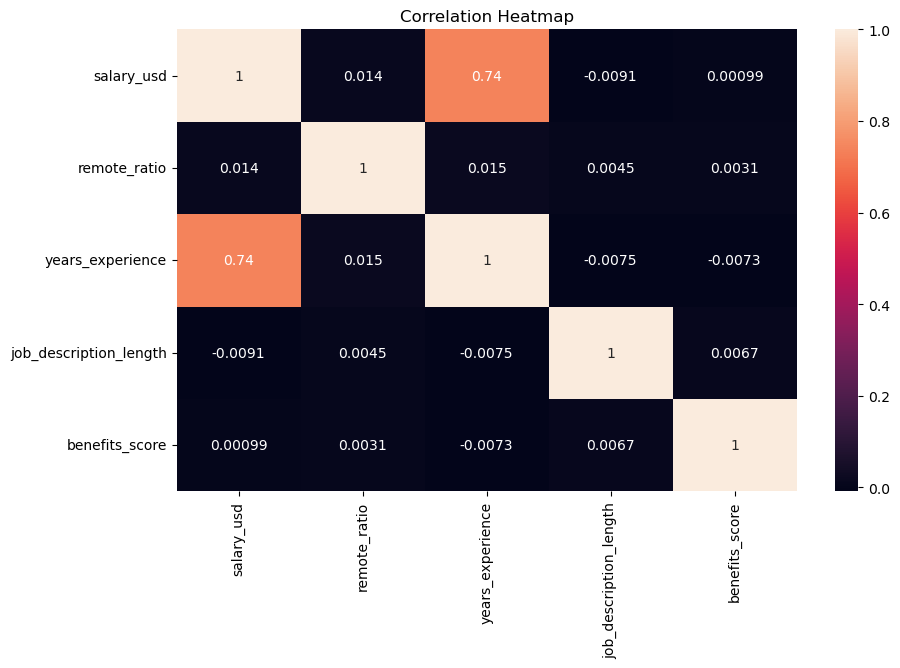

In [27]:
# Correlation analysis
plt.figure(figsize=(10,6))
corr = df.select_dtypes(include=np.number).corr()
sns.heatmap(corr,annot=True)
plt.title("Correlation Heatmap")
plt.show()

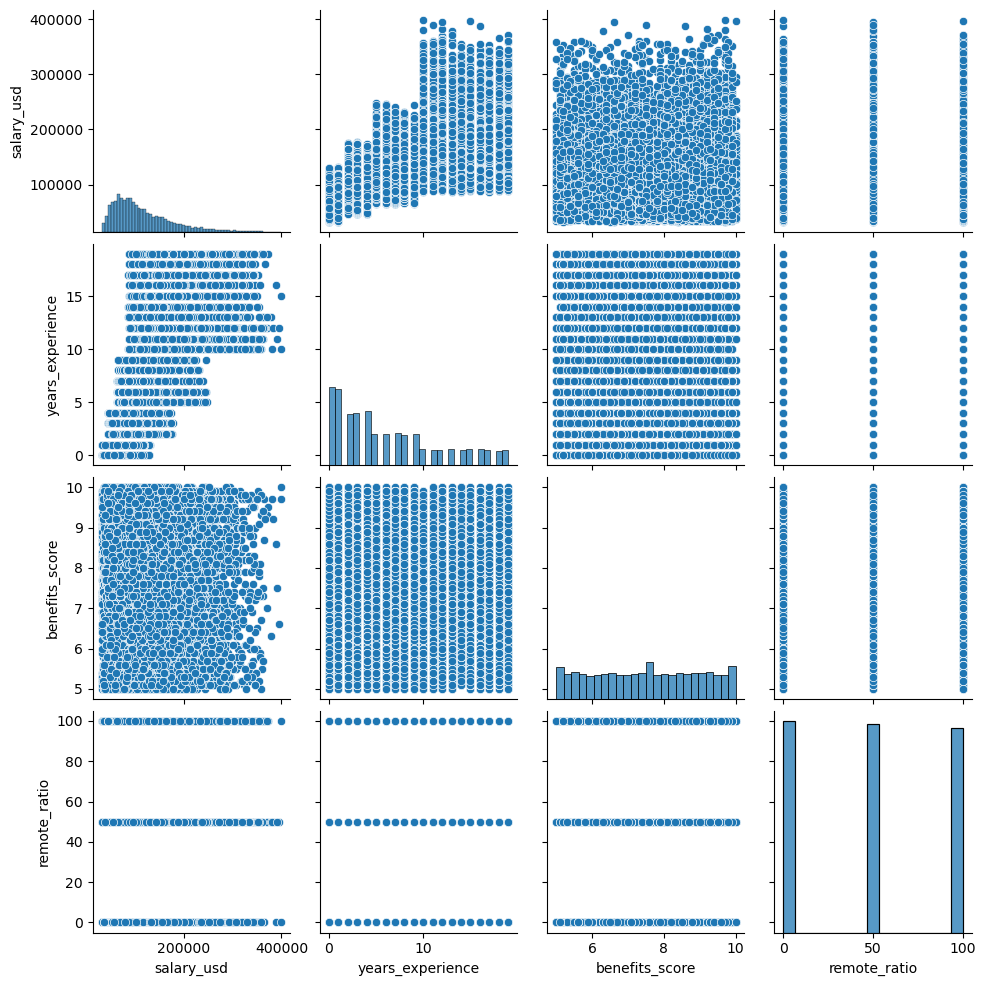

In [28]:
# Multivariate Analysis

# Pairplot / heatmaps
sns.pairplot(df[["salary_usd","years_experience","benefits_score","remote_ratio"]])
plt.show()

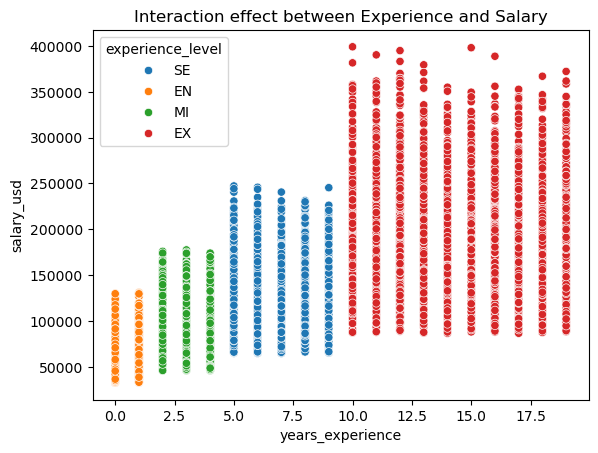

In [29]:
# Interaction
sns.scatterplot(data=df, x="years_experience", y="salary_usd",hue="experience_level")
plt.title("Interaction effect between Experience and Salary")
plt.show()

Understand patterns and relationships: According to the experience level, salary varies from person to person

Step 5: Outlier Detection & Treatment

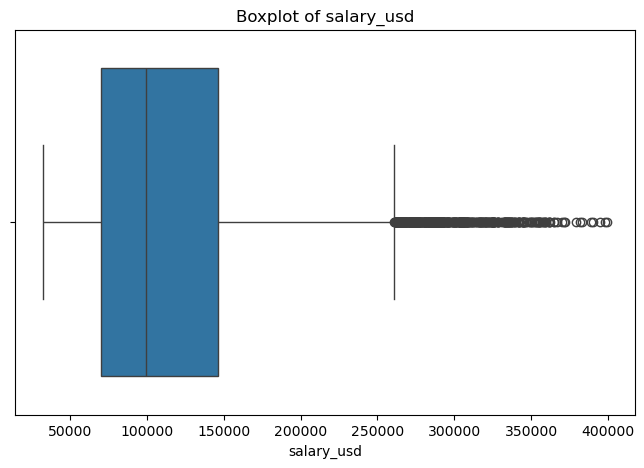

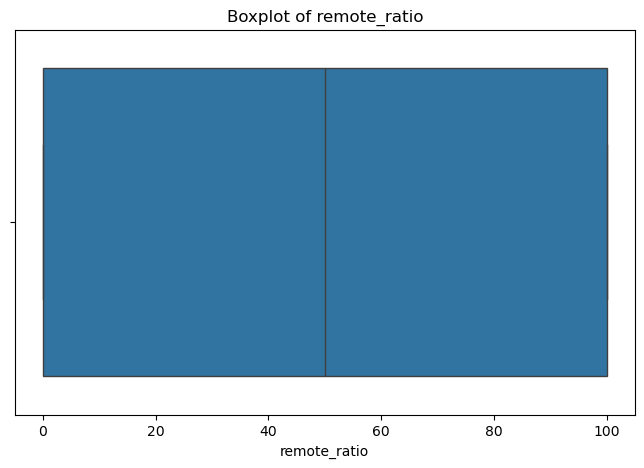

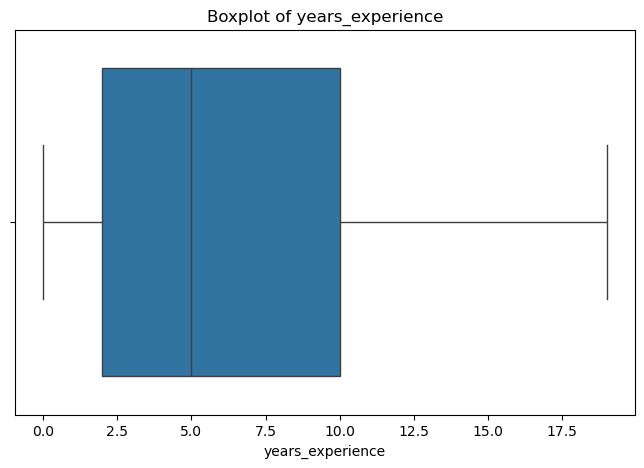

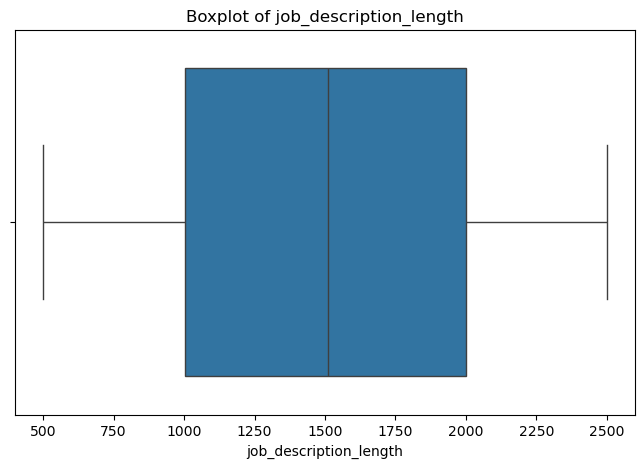

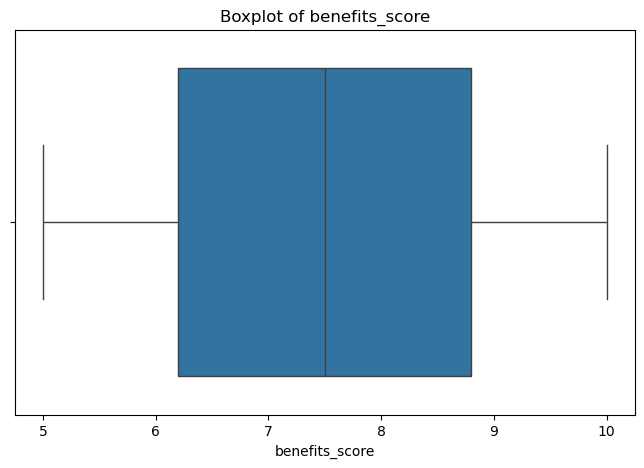

In [30]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

In [31]:
# IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[col] < lower) | (df[col] > upper)]

    print(f"\nOutliers in {col}:",outliers.shape[0])


Outliers in salary_usd: 483

Outliers in remote_ratio: 0

Outliers in years_experience: 0

Outliers in job_description_length: 0

Outliers in benefits_score: 0


In [32]:
# Z-score
from scipy.stats import zscore
z_scores = np.abs(zscore(df[num_cols]))
outliers = (z_scores > 3)
print("Outliers Detected Using Z-Score:",outliers.sum())

Outliers Detected Using Z-Score: 203


In [33]:
# Remove Outlier using IQR
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("Shape After Outlier Removal:",df.shape)

Shape After Outlier Removal: (14517, 19)


In [34]:
# Capping
for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    df[col] = df[col].clip(lower_bound, upper_bound)

print("Shape After Outlier Removal:",df.shape)

Shape After Outlier Removal: (14517, 19)


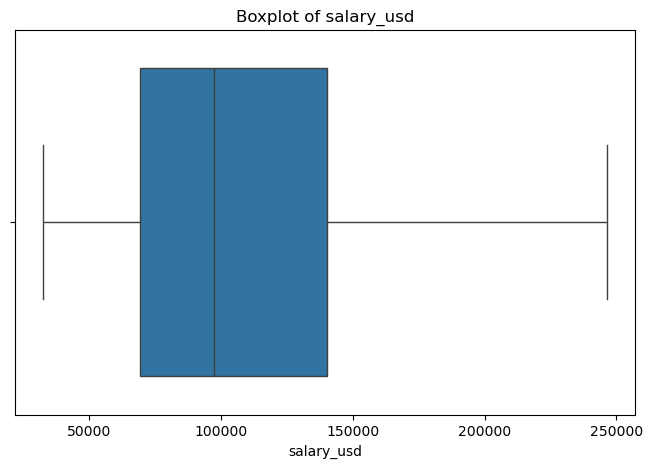

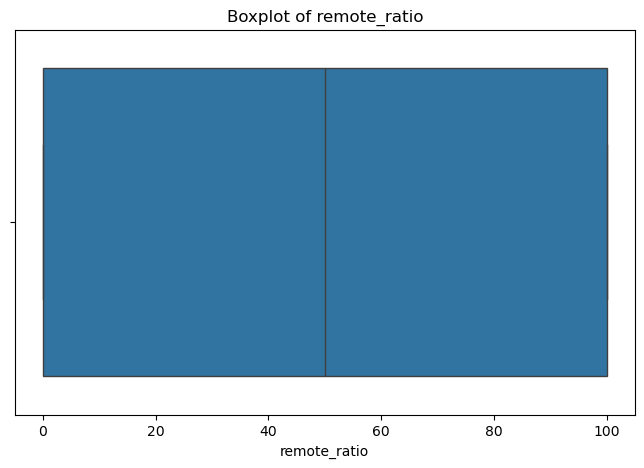

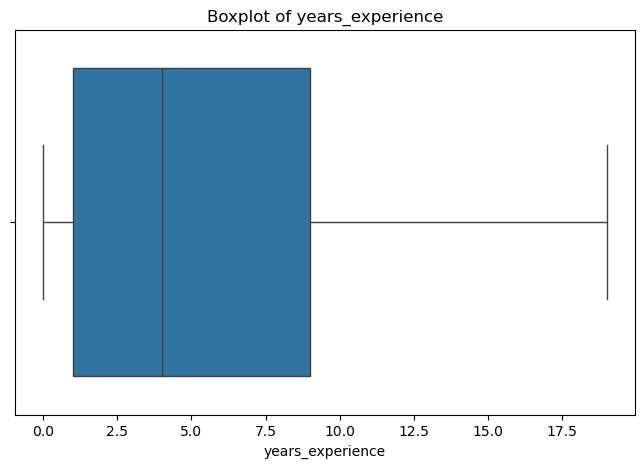

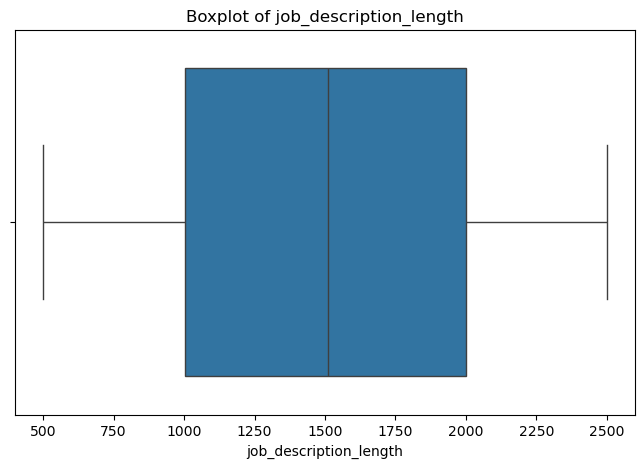

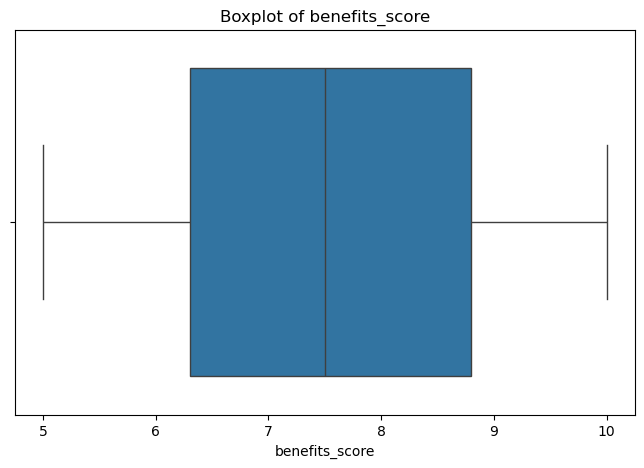

In [35]:
# Boxplots
for col in num_cols:
    plt.figure(figsize=(8,5))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.xlabel(col)
    plt.show()

Step 6: Feature Encoding

In [36]:
# convert to datetime
df['posting_date'] = pd.to_datetime(df['posting_date'])
df['application_deadline'] = pd.to_datetime(df['application_deadline'])

# create new feature
df['days_to_deadline'] = ( df['application_deadline'] - df['posting_date']).dt.days

# optional extra date features
df['posting_month'] = df['posting_date'].dt.month
df['posting_dayofweek'] = df['posting_date'].dt.dayofweek

# drop original datetime columns
df.drop(['posting_date', 'application_deadline'],axis=1,inplace=True)

In [37]:
df.drop(['job_id'],axis=1,inplace=True)

In [38]:
from sklearn.preprocessing import LabelEncoder
# Label Encoding
le = LabelEncoder()
cat_cols = df.select_dtypes(include='object').columns

for col in cat_cols:
    df[col] = le.fit_transform(df[col])

df.head()

,job_title,salary_usd,salary_currency,experience_level,employment_type,company_location,company_size,employee_residence,remote_ratio,required_skills,education_required,years_experience,industry,job_description_length,benefits_score,company_name,days_to_deadline,posting_month,posting_dayofweek
0,3,90376,2,3,0,3,1,3,50,12566,1,9,0,1076,5.9,14,20,10,4
1,4,61895,2,0,0,2,1,9,100,1728,2,1,9,1268,5.2,15,52,11,2
2,5,152626,2,2,1,17,0,15,0,4999,0,2,2,1974,9.4,3,20,3,1
3,16,80215,2,3,1,8,1,8,50,11304,3,7,1,1345,8.6,9,63,12,0
4,1,54624,0,0,3,6,2,14,100,6395,2,0,9,1989,6.6,1,69,4,1


Step 7 & 8: Feature Scaling & Train-Test Split

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [40]:
X = df.drop('salary_usd', axis=1)
y = df['salary_usd']

In [41]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training Shape:",X_train.shape)
print("Testing Shape:",X_test.shape)

Training Shape: (11613, 18)
Testing Shape: (2904, 18)


In [42]:
# Standard Scaler
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

AI Job Salry model shows that salary is influenced by multiple factors such as experience, skills, company size and  geographical location.

## Sprint 2

In [43]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

Step 1: Baseline Model

In [44]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [45]:
y_pred_lr = lr.predict(X_test_scaled)
print(y_pred_lr)

[101893.15514816  54239.76453105 156887.84196591 ... 140281.44371927
  95178.64917117  52827.43416074]


In [46]:
# MAE
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(mae_lr)

23450.65371943741


In [47]:
# RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(rmse_lr)

30243.70555580173


In [48]:
# R2 score
r2_lr = r2_score(y_test, y_pred_lr)
print(r2_lr)

0.6392776813204306


Step 2: Train Multiple Models

In [49]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

In [50]:
# 1. Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred_lr = lr.predict(X_test_scaled)
print(y_pred_lr)

[101893.15514816  54239.76453105 156887.84196591 ... 140281.44371927
  95178.64917117  52827.43416074]


In [52]:
# MAE
mae_lr = mean_absolute_error(y_test, y_pred_lr)
print(mae_lr)

23450.65371943741


In [53]:
# RMSE
rmse_lr = np.sqrt(mean_squared_error(y_test, y_pred_lr))
print(rmse_lr)

30243.70555580173


In [54]:
# R2 score
r2_lr = r2_score(y_test, y_pred_lr)
print(r2_lr)

0.6392776813204306


In [55]:
# 2. Decision Tree Regressor
dt = DecisionTreeRegressor(random_state = 42)
# train
dt.fit(X_train, y_train)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_l

In [56]:
# prediction
y_pred_dt = dt.predict(X_test)
print(y_pred_dt)

[ 65948.  74653. 157471. ... 153782.  79340.  51083.]


In [57]:
# Evaluation
# MAE
mae_dt = mean_absolute_error(y_test, y_pred_dt)
print(mae_dt)

17139.852961432505


In [58]:
# RMSE
rmse_dt = np.sqrt(mean_squared_error(y_test, y_pred_dt))
print(rmse_dt)

23795.836617790195


In [59]:
# R2 score
r2_dt = r2_score(y_test, y_pred_dt)
print(r2_dt)

0.7766916471251901


In [60]:
# 3. Random Forest
rf = RandomForestRegressor(n_estimators=100,random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [61]:
y_pred_rf = rf.predict(X_test)
print(y_pred_rf)

[ 83872.16  72180.68 188631.68 ... 146064.9   88950.35  44647.37]


In [62]:
# MAE
mae_rf = mean_absolute_error(y_test, y_pred_rf)
print(mae_rf)

13130.208257575758


In [63]:
# RMSE
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
print(rmse_rf)

17411.9329285735


In [64]:
# R2 score
r2_rf = r2_score(y_test, y_pred_rf)
print(r2_rf)

0.8804369507188952


In [65]:
# 4. Gradient Boosting Regressor
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [66]:
# prediction
y_pred_gb = gb.predict(X_test)
print(y_pred_gb)

[ 88016.31197268  84785.39957888 184232.1701348  ... 135302.1499521
  95378.8197731   39116.25249006]


In [67]:
# MAE
mae_gb = mean_absolute_error(y_test, y_pred_gb)
print(mae_gb)

13230.086688003408


In [68]:
# RMSE
rmse_gb = np.sqrt(mean_squared_error(y_test, y_pred_gb))
print(rmse_gb)

17568.646756335773


In [69]:
# R2 score
r2_gb = r2_score(y_test, y_pred_gb)
print(r2_gb)

0.8782750421044481


In [70]:
results = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'MAE':[
        mae_lr,
        mae_dt,
        mae_rf,
        mae_gb
    ],
    'RMSE':[
        rmse_lr,
        rmse_dt,
        rmse_rf,
        rmse_gb
    ],
    'R2 Score':[
        r2_lr,
        r2_dt,
        r2_rf,
        r2_gb
    ]
})

results.sort_values(
    by='R2 Score',
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,13130.208258,17411.932929,0.880437
3,Gradient Boosting,13230.086688,17568.646756,0.878275
1,Decision Tree,17139.852961,23795.836618,0.776692
0,Linear Regression,23450.653719,30243.705556,0.639278


Step 4: Overfitting & Underfitting Check

In [71]:
# Train prediction
y_train_pred_lr = lr.predict(X_train_scaled)
# Test prediction
y_test_pred_lr = lr.predict(X_test_scaled)

# R2 scores
train_r2_lr = r2_score(y_train, y_train_pred_lr)
test_r2_lr = r2_score(y_test, y_test_pred_lr)

print("Linear Regression")
print("Train R2:", train_r2_lr)
print("Test R2:", test_r2_lr)

Linear Regression
Train R2: 0.6360699066847098
Test R2: 0.6392776813204306


In [72]:
# Train prediction
y_train_pred_dt = dt.predict(X_train)

# Test prediction
y_test_pred_dt = dt.predict(X_test)

# R2 scores
train_r2_dt = r2_score(y_train, y_train_pred_dt)
test_r2_dt = r2_score(y_test, y_test_pred_dt)

print("Decision Tree")
print("Train R2:", train_r2_dt)
print("Test R2:", test_r2_dt)

Decision Tree
Train R2: 1.0
Test R2: 0.7766916471251901


In [73]:
# Train prediction
y_train_pred_rf = rf.predict(X_train)

# Test prediction
y_test_pred_rf = rf.predict(X_test)

# R2 scores
train_r2_rf = r2_score(y_train, y_train_pred_rf)
test_r2_rf = r2_score(y_test, y_test_pred_rf)

print("Random Forest")
print("Train R2:", train_r2_rf)
print("Test R2:", test_r2_rf)

Random Forest
Train R2: 0.9828739974695258
Test R2: 0.8804369507188952


In [74]:
# Train prediction
y_train_pred_gb = gb.predict(X_train)

# Test prediction
y_test_pred_gb = gb.predict(X_test)

# R2 scores
train_r2_gb = r2_score(y_train, y_train_pred_gb)
test_r2_gb = r2_score(y_test, y_test_pred_gb)

print("Gradient Boosting")
print("Train R2:", train_r2_gb)
print("Test R2:", test_r2_gb)

Gradient Boosting
Train R2: 0.880552318373804
Test R2: 0.8782750421044481


In [75]:
overfit_check = pd.DataFrame({
    'Model':[
        'Linear Regression',
        'Decision Tree',
        'Random Forest',
        'Gradient Boosting'
    ],
    'Train R2':[
        train_r2_lr,
        train_r2_dt,
        train_r2_rf,
        train_r2_gb
    ],
    'Test R2':[
        test_r2_lr,
        test_r2_dt,
        test_r2_rf,
        test_r2_gb
    ]
})

# Gap between train and test
overfit_check['Gap'] = (
    overfit_check['Train R2']
    -
    overfit_check['Test R2']
)

print(overfit_check)

               Model  Train R2   Test R2       Gap
0  Linear Regression  0.636070  0.639278 -0.003208
1      Decision Tree  1.000000  0.776692  0.223308
2      Random Forest  0.982874  0.880437  0.102437
3  Gradient Boosting  0.880552  0.878275  0.002277


Step 5: Model Comparison Table

In [76]:
best_model = overfit_check.iloc[0]

print("Best Model:", best_model["Model"])
print("Best R2 Score:", best_model["Train R2"])

Best Model: Linear Regression
Best R2 Score: 0.6360699066847098


## SPRINT 3: OPTIMIZATION & FINAL MODEL

Step 1 & 2: Feature Engineering & Feature Selection

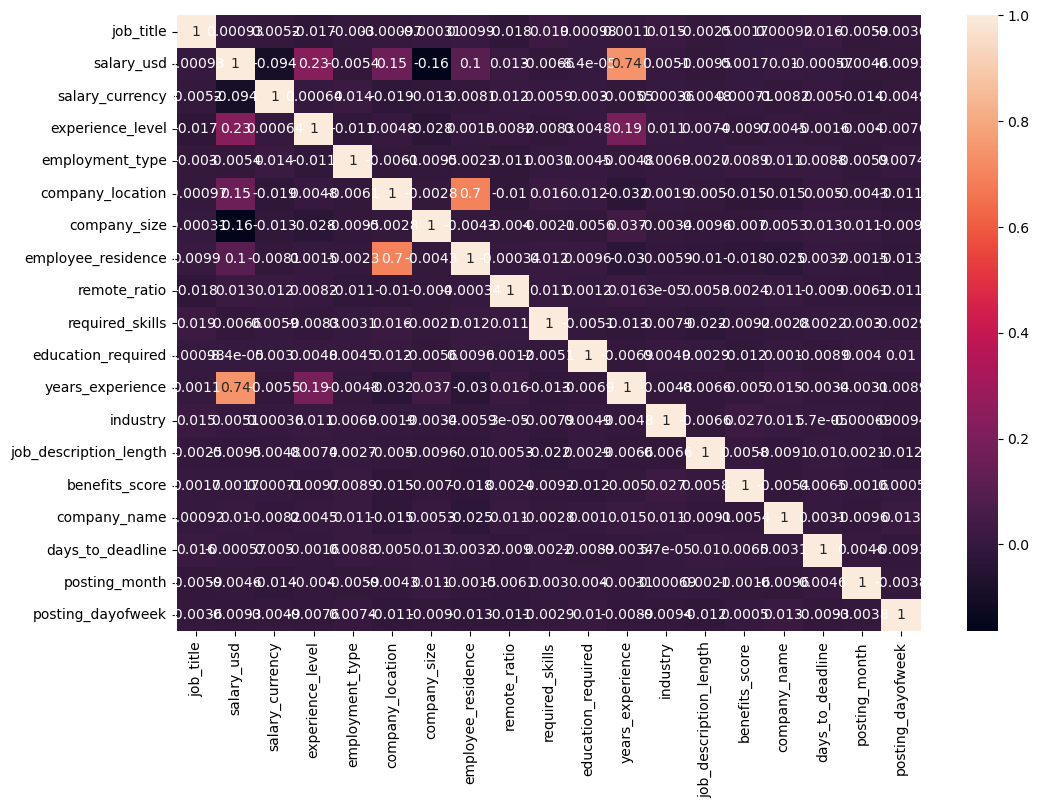

In [77]:
# Correlation matrix
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True),annot=True)

plt.show()

In [78]:
rf = RandomForestRegressor(random_state=42)
rf.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [79]:
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf.feature_importances_
})

importance_df = importance_df.sort_values(by='Importance',ascending=False)
print(importance_df)

                   Feature  Importance
10        years_experience    0.547538
4         company_location    0.218051
2         experience_level    0.076428
5             company_size    0.044748
12  job_description_length    0.012569
15        days_to_deadline    0.012279
8          required_skills    0.012132
13          benefits_score    0.010907
0                job_title    0.009047
11                industry    0.008624
14            company_name    0.008552
1          salary_currency    0.008134
16           posting_month    0.007655
6       employee_residence    0.006483
17       posting_dayofweek    0.006030
3          employment_type    0.003818
9       education_required    0.003798
7             remote_ratio    0.003208


In [80]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lr = LinearRegression()
rfe = RFE(estimator=lr,n_features_to_select=10)
rfe.fit(X_train_scaled,y_train)

,"estimator estimator: ``Estimator`` instanceA supervised learning estimator with a ``fit`` method that providesinformation about feature importance(e.g. `coef_`, `feature_importances_`).",LinearRegression()
,"n_features_to_select n_features_to_select: int or float, default=NoneThe number of features to select. If `None`, half of the features areselected. If integer, the parameter is the absolute number of featuresto select. If float between 0 and 1, it is the fraction of features toselect... versionchanged:: 0.24 Added float values for fractions.",10
,"step step: int or float, default=1If greater than or equal to 1, then ``step`` corresponds to the(integer) number of features to remove at each iteration.If within (0.0, 1.0), then ``step`` corresponds to the percentage(rounded down) of features to remove at each iteration.",1
,"verbose verbose: int, default=0Controls verbosity of output.",0
,"importance_getter importance_getter: str or callable, default='auto'If 'auto', uses the feature importance either through a `coef_`or `feature_importances_` attributes of estimator.Also accepts a string that specifies an attribute name/pathfor extracting feature importance (implemented with `attrgetter`).For example, give `regressor_.coef_` in case of:class:`~sklearn.compose.TransformedTargetRegressor` or`named_steps.clf.feature_importances_` in case ofclass:`~sklearn.pipeline.Pipeline` with its last step named `clf`.If `callable`, overrides the default feature importance getter.The callable is passed with the fitted estimator and it shouldreturn importance for each feature... versionadded:: 0.24",'auto'
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [81]:
selected_features = X.columns[rfe.support_]
print(selected_features)

Index(['salary_currency', 'experience_level', 'employment_type',
       'company_location', 'company_size', 'employee_residence',
       'years_experience', 'industry', 'job_description_length',
       'posting_dayofweek'],
      dtype='object')


Step 3: Hyperparameter Tuning

Linear Regression 

In [82]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import GridSearchCV

params = {'fit_intercept':[True, False]}

grid_lr = GridSearchCV(
    LinearRegression(),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_lr.fit(X_train_scaled, y_train)

print("Best Parameter:",grid_lr.best_params_)
print("Best Score:",grid_lr.best_score_)

Best Parameter: {'fit_intercept': True}
Best Score: 0.6348082350081926


Decision Tree

In [83]:
from sklearn.tree import DecisionTreeRegressor

params = {
    'max_depth':[3,5,10,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

grid_dt = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2'
)

grid_dt.fit(X_train_scaled, y_train)

print("Best Parameter:",grid_dt.best_params_)
print("Best Score:",grid_dt.best_score_)

Best Parameter: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best Score: 0.8442583229526658


Random Forest Regressor

In [84]:
from sklearn.ensemble import RandomForestRegressor

params = {
    'n_estimators':[100,200],
    'max_depth':[5,10,None],
    'min_samples_split':[2,5],
    'min_samples_leaf':[1,2]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_rf.fit(X_train_scaled, y_train)

print("Best Parameter:",grid_rf.best_params_)
print("Best Score:",grid_rf.best_score_)

Best Parameter: {'max_depth': 10, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}
Best Score: 0.8774404915507876


Gradient Boosting Regressor

In [85]:
from sklearn.ensemble import GradientBoostingRegressor

params = {
    'n_estimators':[100,200],
    'learning_rate':[0.01,0.1,0.2],
    'max_depth':[3,5,7]
}

grid_gb = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid_gb.fit(X_train_scaled, y_train)

print(grid_gb.best_params_)
print(grid_gb.best_score_)

{'learning_rate': 0.1, 'max_depth': 5, 'n_estimators': 100}
0.8831536503839363


In [86]:
# Model comparison
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Best R2":[
        grid_lr.best_score_,
        grid_dt.best_score_,
        grid_rf.best_score_,
        grid_gb.best_score_
    ]
})

print(comparison)

               Model   Best R2
0  Linear Regression  0.634808
1      Decision Tree  0.844258
2      Random Forest  0.877440
3  Gradient Boosting  0.883154


In [87]:
best_model = comparison.loc[
    comparison['Best R2'].idxmax()
]

print(best_model)

Model      Gradient Boosting
Best R2             0.883154
Name: 3, dtype: object


RandomizedSearchCV

In [88]:
from sklearn.model_selection import RandomizedSearchCV

In [89]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV

rf = RandomForestRegressor(random_state=42)

params = {
    'n_estimators':[100,200,300],
    'max_depth':[5,10,15,None],
    'min_samples_split':[2,5,10],
    'min_samples_leaf':[1,2,4]
}

random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=params,
    n_iter=10,
    cv=5,
    scoring='r2',
    random_state=42,
    n_jobs=-1
)

random_rf.fit(X_train_scaled, y_train)

print(random_rf.best_params_)
print(random_rf.best_score_)

{'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 10}
0.8775413149641406


In [91]:
best_rf = grid_rf.best_estimator_

In [92]:
best_rf.fit(X_train_scaled,y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",10
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

Step 5: Final Evaluation

In [93]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [94]:
y_pred = best_rf.predict(X_test_scaled)

In [95]:
mae = mean_absolute_error(y_test,y_pred)
rmse = np.sqrt(mean_squared_error(y_test,y_pred))
r2 = r2_score(y_test,y_pred)

In [96]:
print("MAE :", mae)
print("RMSE :", rmse)
print("R2 Score :", r2)

MAE : 13040.782194540494
RMSE : 17264.161882609224
R2 Score : 0.8824577470305096


In [97]:
print("Train Score :",best_rf.score(X_train_scaled,y_train))
print("Test Score :",best_rf.score(X_test_scaled,y_test))

Train Score : 0.9341179086870951
Test Score : 0.8824577470305096


Step 6: Model Serialization

In [98]:
import joblib
joblib.dump(best_rf,'salary_prediction_model.pkl')

['salary_prediction_model.pkl']

In [99]:
model = joblib.load('salary_prediction_model.pkl')

# SPRINT 4: DEPLOYMENT & MLOPS

Step 1: Build ML Pipeline

In [100]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestRegressor

pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', RandomForestRegressor(random_state=42))
])

pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_

In [101]:
X = df[['years_experience',
        'benefits_score',
        'remote_ratio']]

y = df['salary_usd']

In [102]:
prediction = pipeline.predict(X_test)
print(prediction)

[ 83506.64  72292.73 188227.87 ... 146064.9   89080.03  44750.56]


In [103]:
pipeline.fit(X, y)

joblib.dump(pipeline,'salary_pipeline.pkl')

['salary_pipeline.pkl']

In [104]:
!jupyter nbconvert --to script "AI Job Salary Prediction.ipynb"

[NbConvertApp] Converting notebook AI Job Salary Prediction.ipynb to script
[NbConvertApp] Writing 18747 bytes to AI Job Salary Prediction.py


# Conclusion

This project predicts AI job salaries based on factors such as experience, skills, company details, and job requirements. The analysis showed that years of experience have a major impact on salary, with experienced professionals generally earning higher salaries. Features like company size, industry, benefits offered, and remote work options also influence salary levels. Different machine learning models were trained and compared to find the best-performing model. The final model helps companies make better salary decisions and helps job seekers understand salary expectations.
